In [3]:
# prompt: mount google drive navigate to dir GEE_Exports

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os
os.chdir('/content/drive/My Drive/6400_final')


Mounted at /content/drive


In [4]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 75.4 MB/s eta 0:00:00


In [5]:
import geemap
import geopandas as gpd
import folium
from shapely.geometry import shape
import rasterio

In [6]:
cd raw

/content/drive/My Drive/6400_final/raw



--- File: dakar_building_presence_height_2023.tif ---
Number of bands: 2
Band 1 Description: building_presence
Band 2 Description: building_height


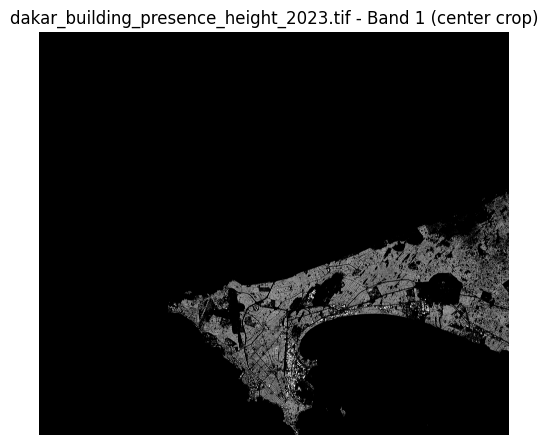


--- File: dakar_building_presence_height_2022.tif ---
Number of bands: 2
Band 1 Description: building_presence
Band 2 Description: building_height


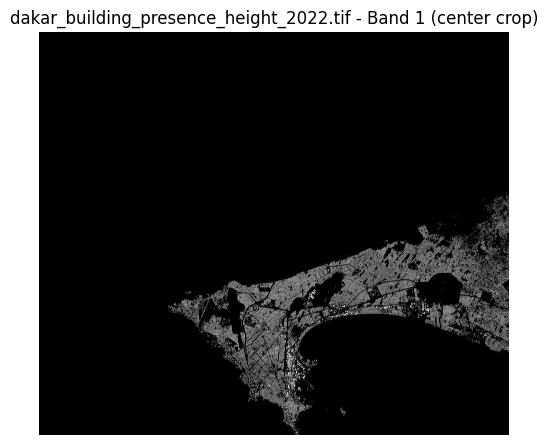


--- File: dakar_building_presence_height_2017.tif ---
Number of bands: 2
Band 1 Description: building_presence
Band 2 Description: building_height


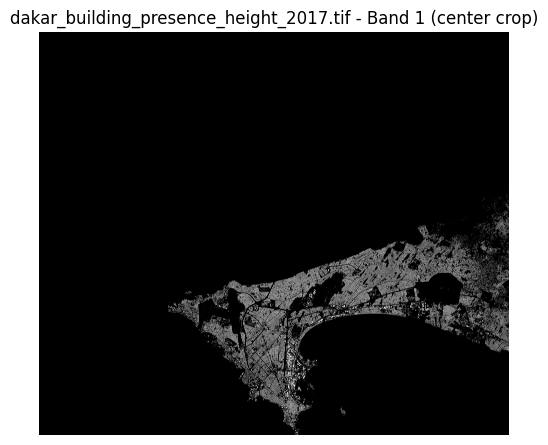


--- File: dakar_building_presence_height_2016.tif ---
Number of bands: 2
Band 1 Description: building_presence
Band 2 Description: building_height


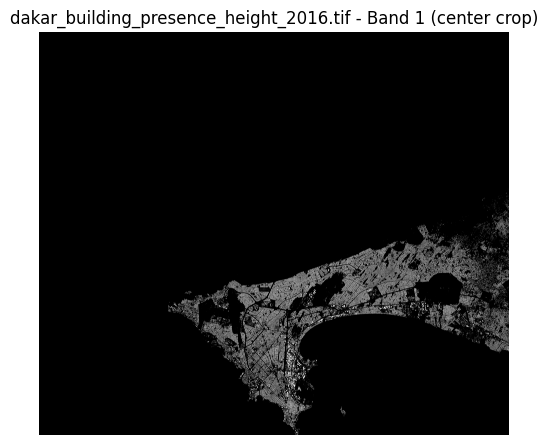

In [8]:
import rasterio
import matplotlib.pyplot as plt
from rasterio.windows import Window
from glob import glob
import os

tif_files = glob(os.path.join('./*.tif'))

for tif_path in tif_files:
    print(f"\n--- File: {os.path.basename(tif_path)} ---")

    with rasterio.open(tif_path) as src:
        print(f"Number of bands: {src.count}")
        for i in range(1, src.count + 1):
            desc = src.descriptions[i - 1] or f"Band {i}"
            print(f"Band {i} Description: {desc}")

        # Optional: read a small center window to reduce RAM
        w, h = src.width // 4, src.height // 4
        window = Window(w, h, src.width // 2, src.height // 2)
        band1 = src.read(1, window=window)

        plt.figure(figsize=(5, 5))
        plt.title(f"{os.path.basename(tif_path)} - Band 1 (center crop)")
        plt.imshow(band1, cmap='gray')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        plt.close()  # Important to free memory

In [ ]:
pip install geopandas rasterio rasterstats networkx

In [1]:
import rasterio
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape

# Parameters
presence_tif = "../dakar_building_presence_height_2016.tif"
#Sophias path

threshold = 0.35

# Open raster
with rasterio.open(presence_tif) as src:
    # Read the full presence mask efficiently as uint8 (0/1)
    # NOTE: For very large rasters, we can do this in chunks (see below)
    presence = src.read(1)
    mask = presence > threshold

    binary_presence = mask.astype("uint8")  # Convert boolean mask to 0/1 image

    results = (
      {'properties': {'value': v}, 'geometry': s}
      for s, v in shapes(binary_presence, mask=mask, transform=src.transform)
      if v == 1
  )

    # Convert to GeoDataFrame
    geoms = list(results)
    gdf = gpd.GeoDataFrame.from_features(geoms)
    gdf = gdf.set_crs(src.crs)

# Optional: project to UTM for accurate area
gdf = gdf.to_crs(epsg=32633)  # or appropriate UTM for your region

# Filter small objects (noise)
gdf["area"] = gdf.geometry.area
gdf = gdf[gdf["area"] > 10]  # remove tiny polygons

# Save to GeoJSON
gdf.to_file("generated/buildings_2017.geojson", driver="GeoJSON")

ModuleNotFoundError: No module named 'rasterio'

In [ ]:
pip install rasterstats

In [ ]:
import rasterio

# Check CRS of raster
with rasterio.open(presence_tif) as src:
    print("Raster CRS:", src.crs)

gdf["area"] = gdf.geometry.area
gdf = gdf.to_crs("EPSG:4326")



Raster CRS: EPSG:4326


In [9]:
import geopandas as gpd

# Load the land use data
landuse_gdf = gpd.read_file("../generated/dakar_landuse_combined.gpkg")

# Check the available columns
print(landuse_gdf.columns)

# Peek at a few rows
landuse_gdf.head()

Index(['C_L1', 'N_L1', 'C_L2', 'N_L2', 'C_L3', 'N_L3', 'C_L4', 'N_L4', 'AREA',
       'ID', 'LandUseClass', 'geometry'],
      dtype='object')


,C_L1,N_L1,C_L2,N_L2,C_L3,N_L3,C_L4,N_L4,AREA,ID,LandUseClass,geometry
0,40000,Wetlands,40000,Wetlands,40000,Wetlands,40000,Wetlands,675497.829095,1,Other,"POLYGON ((240603.381 1632180.149, 240659.504 1..."
1,10000,Artificial Surfaces,12000,"Industrial, Commercial, Public, Military, Priv...",12300,Port,12300,Port,3496.675587,2,Commercial,"POLYGON ((238564.614 1623697.416, 238518.959 1..."
2,10000,Artificial Surfaces,12000,"Industrial, Commercial, Public, Military, Priv...",12300,Port,12300,Port,3411.767770,3,Commercial,"POLYGON ((238834.159 1625673.018, 238685.244 1..."
3,10000,Artificial Surfaces,11000,Urban Fabric,11100,Continuous Urban Fabric (Sealing level: 80% - ...,11100,High density continuous residential urban fabr...,653.481487,4,Residential,"POLYGON ((235954.169 1626865.915, 235937.527 1..."
4,30000,Natural and Semi-natural Areas,33000,Bare land,33000,Bare land,33000,Bare land,459696.517200,5,Other,"POLYGON ((256749.245 1627070.75, 256789.786 16..."


In [ ]:
import geopandas as gpd

# Load building footprints and land use layer
gdf = gpd.read_file("../generated/buildings_2017.geojson")  # Your building polygons
landuse_gdf = gpd.read_file("../generated/dakar_landuse_combined.gpkg")  # Land use polygons

# Ensure both GeoDataFrames have the same CRS
if landuse_gdf.crs != gdf.crs:
    landuse_gdf = landuse_gdf.to_crs(gdf.crs)

# Perform all-to-all spatial overlay to compute intersections
intersections = gpd.overlay(gdf, landuse_gdf, how="intersection")

# Compute area of intersection for each geometry pair
intersections["intersect_area"] = intersections.geometry.area

# Now identify, for each building geometry, the land use polygon with max overlap
# This assumes your original gdf has an index — we preserve it in the overlay
intersections["building_id"] = intersections.index

# Sort by intersection area (descending) and drop duplicates keeping the largest overlap
dominant_landuse = intersections.sort_values("intersect_area", ascending=False)
dominant_landuse = dominant_landuse.drop_duplicates(subset="building_id")

# Join back to original building GeoDataFrame to preserve non-spatial attributes (like area)
gdf["building_id"] = gdf.index  # Add index column to join on
gdf_landuse = gdf.merge(dominant_landuse[["building_id", "LandUseClass"]], on="building_id", how="left")

# Drop helper column
gdf = gdf_landuse.drop(columns=["building_id"])

In [ ]:
import rasterio
from rasterstats import zonal_stats

# Open raster and get its CRS
with rasterio.open(presence_tif) as src:
    raster_crs = src.crs
    print("Raster CRS:", raster_crs)

# Reproject gdf to match raster CRS
gdf = gdf.to_crs(raster_crs)

# Now compute zonal stats
presence_stats = zonal_stats(gdf, presence_tif, stats=["mean"], band=1, geojson_out=False)
height_stats = zonal_stats(gdf, presence_tif, stats=["mean"], band=2, geojson_out=False)

# Add to GeoDataFrame
gdf["mean_presence"] = [s["mean"] if s["mean"] is not None else 0 for s in presence_stats]
gdf["mean_height"] = [s["mean"] if s["mean"] is not None else 0 for s in height_stats]

Raster CRS: EPSG:4326


/usr/local/lib/python3.11/dist-packages/rasterstats/io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


In [ ]:
print(gdf.columns)

# Peek at a few rows
gdf.head()

Index(['value', 'area', 'geometry', 'LandUseClass', 'mean_presence',
       'mean_height'],
      dtype='object')


,value,area,geometry,LandUseClass,mean_presence,mean_height
0,1.0,41.795761,"POLYGON ((-17.10026 14.94922, -17.10026 14.949...",Other,0.608906,2.906250
1,1.0,229.876262,"POLYGON ((-17.10019 14.94919, -17.10019 14.949...",Other,0.616477,3.800426
2,1.0,20.897812,"POLYGON ((-17.10001 14.94904, -17.10001 14.949...",Other,0.321250,1.429688
3,1.0,62.693788,"POLYGON ((-17.10029 14.94904, -17.10029 14.948...",Other,0.587396,2.776042
4,1.0,125.387118,"POLYGON ((-17.10008 14.94897, -17.10008 14.948...",Other,0.462292,2.796875


In [ ]:
import networkx as nx
from shapely.geometry import Polygon

# Ensure GeoDataFrame is in projected CRS (for square meters)
gdf = gdf.to_crs(epsg=32633)  # UTM Zone 33N (Dakar region)

# Recalculate area in square meters
gdf["area"] = gdf.geometry.area

# Initialize empty graph
G = nx.Graph()

# Add nodes with attributes
for idx, row in gdf.iterrows():
    G.add_node(idx,
               geometry=row.geometry,
               mean_presence=row["mean_presence"],
               mean_height=row["mean_height"],
               LandUseClass=row["LandUseClass"],
               area=row["area"])  # now in square meters

# Build spatial index for efficiency
sindex = gdf.sindex

# Add edges based on shared boundaries
for idx, geom in gdf.geometry.items():
    possible_neighbors_index = list(sindex.intersection(geom.bounds))
    for neighbor_idx in possible_neighbors_index:
        if idx >= neighbor_idx:
            continue  # Avoid duplicate edges or self-edges
        neighbor_geom = gdf.geometry.iloc[neighbor_idx]
        if geom.touches(neighbor_geom):
            shared = geom.intersection(neighbor_geom)
            if shared.is_empty:
                continue
            shared_length = shared.length
            G.add_edge(idx, neighbor_idx, shared_length=shared_length)

In [ ]:
print(gdf["area"].describe())

count    104805.000000
mean       1051.503629
std        3429.504912
min          20.897812
25%         105.382731
50%         294.428070
75%         901.611262
max      365424.606923
Name: area, dtype: float64


In [ ]:
import pickle

with open("generated/building_network_2017.pkl", "wb") as f:
    pickle.dump(G, f)

In [ ]:
import geopandas as gpd
from shapely.geometry import LineString

# Create GeoDataFrame of nodes
node_gdf = gpd.GeoDataFrame.from_dict(
    {n: G.nodes[n] for n in G.nodes},
    orient="index",
    geometry="geometry",
    crs=gdf.crs
)

# Create GeoDataFrame of edges
edge_geoms = []
for u, v, data in G.edges(data=True):
    geom_u = G.nodes[u]["geometry"]
    geom_v = G.nodes[v]["geometry"]
    shared = geom_u.intersection(geom_v)
    if not shared.is_empty:
        edge_geoms.append({
            "source": u,
            "target": v,
            "shared_length": data["shared_length"],
            "geometry": shared
        })

edge_gdf = gpd.GeoDataFrame(edge_geoms, crs=gdf.crs)

In [10]:
import geopandas as gpd
node_gdf = gpd.read_file("../generated/network_nodes_2017.geojson")
edge_gdf = gpd.read_file("../generated/network_edges_2017.geojson")

In [ ]:
# node_gdf.to_file("generated/network_nodes_2017.geojson", driver="GeoJSON")
# edge_gdf.to_file("generated/network_edges_2017.geojson", driver="GeoJSON")

In [12]:
print("Node GDF columns:", node_gdf.columns)
print("Edge GDF columns:", edge_gdf.columns)

print("\nSample node data:")
print(node_gdf.head())

print("\nSample edge data:")
print(edge_gdf.head())

Node GDF columns: Index(['mean_presence', 'mean_height', 'LandUseClass', 'area', 'geometry'], dtype='object')
Edge GDF columns: Index(['source', 'target', 'shared_length', 'geometry'], dtype='object')

Sample node data:
   mean_presence  mean_height LandUseClass        area  \
0       0.608906     2.906250        Other   41.795761   
1       0.616477     3.800426        Other  229.876262   
2       0.321250     1.429688        Other   20.897812   
3       0.587396     2.776042        Other   62.693788   
4       0.462292     2.796875        Other  125.387118   

                                            geometry  
0  POLYGON ((-3119275.754 1936411.173, -3119276.4...  
1  POLYGON ((-3119267.598 1936405.153, -3119268.3...  
2  POLYGON ((-3119248.32 1936383.239, -3119249.06...  
3  POLYGON ((-3119283.915 1936389.012, -3119285.3...  
4  POLYGON ((-3119258.703 1936375.529, -3119260.9...  

Sample edge data:
   source  target  shared_length                          geometry
0       0      

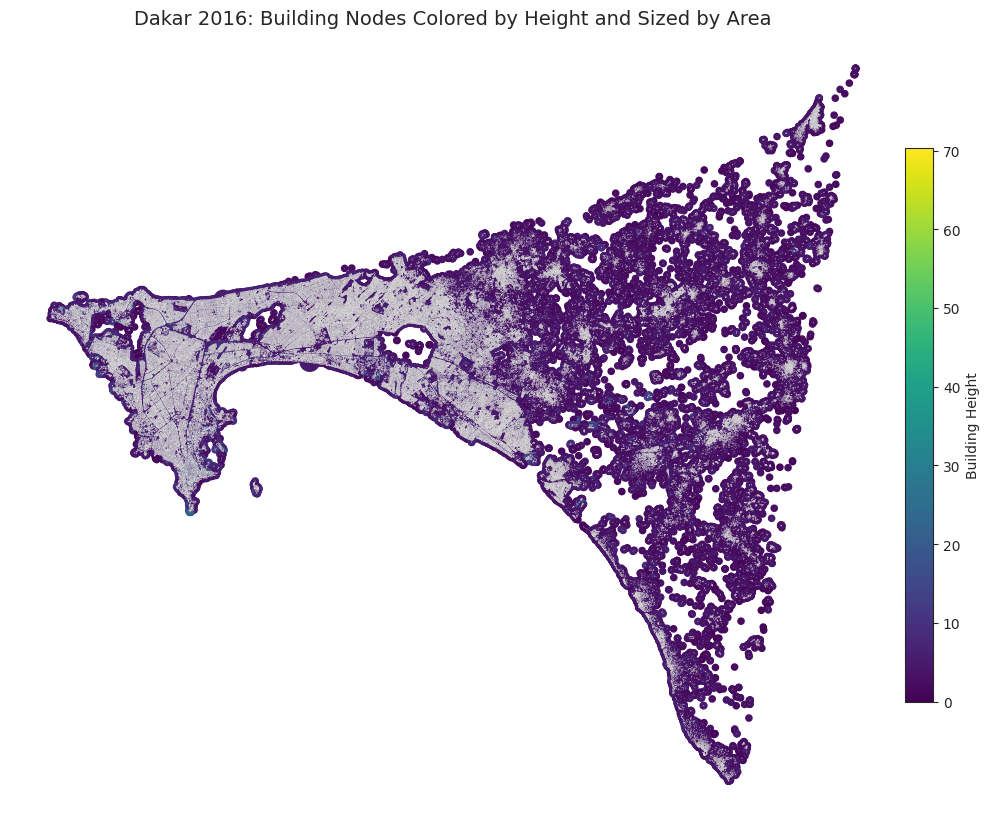

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import geopandas as gpd

# --- Step 1: Prepare base data ---
# Assume node_gdf contains building polygons with 'mean_height' and 'area'
centroids = node_gdf.copy()
centroids['geometry'] = node_gdf.centroid

# --- Step 2: Normalize color by height ---
height = centroids['mean_height']
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=height.min(), vmax=height.max())
colors = cmap(norm(height))

# --- Step 3: Normalize marker size by area ---
area = centroids['area']
area_norm = (area - area.min()) / (area.max() - area.min())
sizes = 20 + 180 * area_norm  # Adjust 20 and 180 as needed

# --- Step 4: Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

# Optional: plot base polygons for context
node_gdf.boundary.plot(ax=ax, linewidth=0.2, color='lightgray')

# Plot centroids as colored and sized points
centroids.plot(ax=ax, marker='o', color=colors, markersize=sizes)

# --- Step 5: Add colorbar for height ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []  # Dummy data
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.01)
cbar.set_label("Building Height", fontsize=10)

# --- Final touches ---
ax.set_title("Dakar 2016: Building Nodes Colored by Height and Sized by Area", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [13]:
import networkx as nx

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

import pandas as pd

# Extract node attributes
node_attrs = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')

# Summary statistics
print("\n--- Node Attribute Summary ---")
print(node_attrs.describe())

NameError: name 'G' is not defined

In [ ]:
edge_attrs = pd.DataFrame(
    [(u, v, d['shared_length']) for u, v, d in G.edges(data=True)],
    columns=["source", "target", "shared_length"]
)

print("\n--- Edge Attribute Summary ---")
print(edge_attrs["shared_length"].describe())
isolated = list(nx.isolates(G))
print("Number of isolated nodes:", len(isolated))
components = list(nx.connected_components(G))
print("Number of connected components:", len(components))

degrees = [deg for _, deg in G.degree()]
print("\n--- Node Degree Summary ---")
print(pd.Series(degrees).describe())


--- Edge Attribute Summary ---
count    18377.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: shared_length, dtype: float64
Number of isolated nodes: 77327
Number of connected components: 87251

--- Node Degree Summary ---
count    104805.000000
mean          0.350689
std           0.712328
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          22.000000
dtype: float64


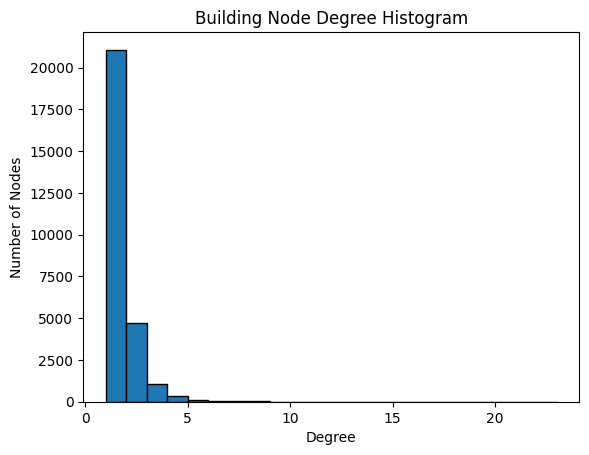

In [ ]:
import matplotlib.pyplot as plt

plt.hist(degrees, bins=range(1, max(degrees)+2), edgecolor='black')
plt.title("Building Node Degree Histogram")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.show()

sample_data/


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
gdf.to_file("generated/buildings_2017.geojson", driver="GeoJSON")

# gdf = gpd.read_file("generated/buildings_2023.geojson")

# Print basic info
print(gdf.info())

# Show first few rows
print(gdf.head())

# Check CRS
print("CRS:", gdf.crs)

# Check attribute columns
print("Columns:", gdf.columns.tolist())

# Summary stats
print(gdf.describe())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 104805 entries, 0 to 104804
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   value          104805 non-null  float64 
 1   area           104805 non-null  float64 
 2   geometry       104805 non-null  geometry
 3   LandUseClass   104805 non-null  object  
 4   mean_presence  104805 non-null  float64 
 5   mean_height    104805 non-null  float64 
dtypes: float64(4), geometry(1), object(1)
memory usage: 4.8+ MB
None
   value        area                                           geometry  \
0    1.0   41.795761  POLYGON ((-3119275.754 1936411.173, -3119276.4...   
1    1.0  229.876262  POLYGON ((-3119267.598 1936405.153, -3119268.3...   
2    1.0   20.897812  POLYGON ((-3119248.32 1936383.239, -3119249.06...   
3    1.0   62.693788  POLYGON ((-3119283.915 1936389.012, -3119285.3...   
4    1.0  125.387118  POLYGON ((-3119258.703 1936375.529, -3119260.9.

In [14]:
node_gdf_2016 = gpd.read_file("../generated/network_nodes_2016.geojson")
edge_gdf_2016 = gpd.read_file("../generated/network_edges_2016.geojson")

node_gdf_2023 = gpd.read_file("../generated/network_nodes_2023.geojson")
edge_gdf_2023 = gpd.read_file("../generated/network_edges_2023.geojson")

In [15]:
def build_graph(node_gdf, edge_gdf):
    G = nx.Graph()

    # Add nodes with attributes
    for idx, row in node_gdf.iterrows():
        G.add_node(idx,
                   mean_presence=row["mean_presence"],
                   mean_height=row["mean_height"],
                   land_use=row["LandUseClass"],
                   area=row["area"],
                   geometry=row["geometry"].centroid)

    # Add edges
    for _, row in edge_gdf.iterrows():
        source = row["source"]
        target = row["target"]
        G.add_edge(source, target,
                   shared_length=row["shared_length"],
                   geometry=row["geometry"])

    return G

G_2016 = build_graph(node_gdf_2016, edge_gdf_2016)
G_2023 = build_graph(node_gdf_2023, edge_gdf_2023)

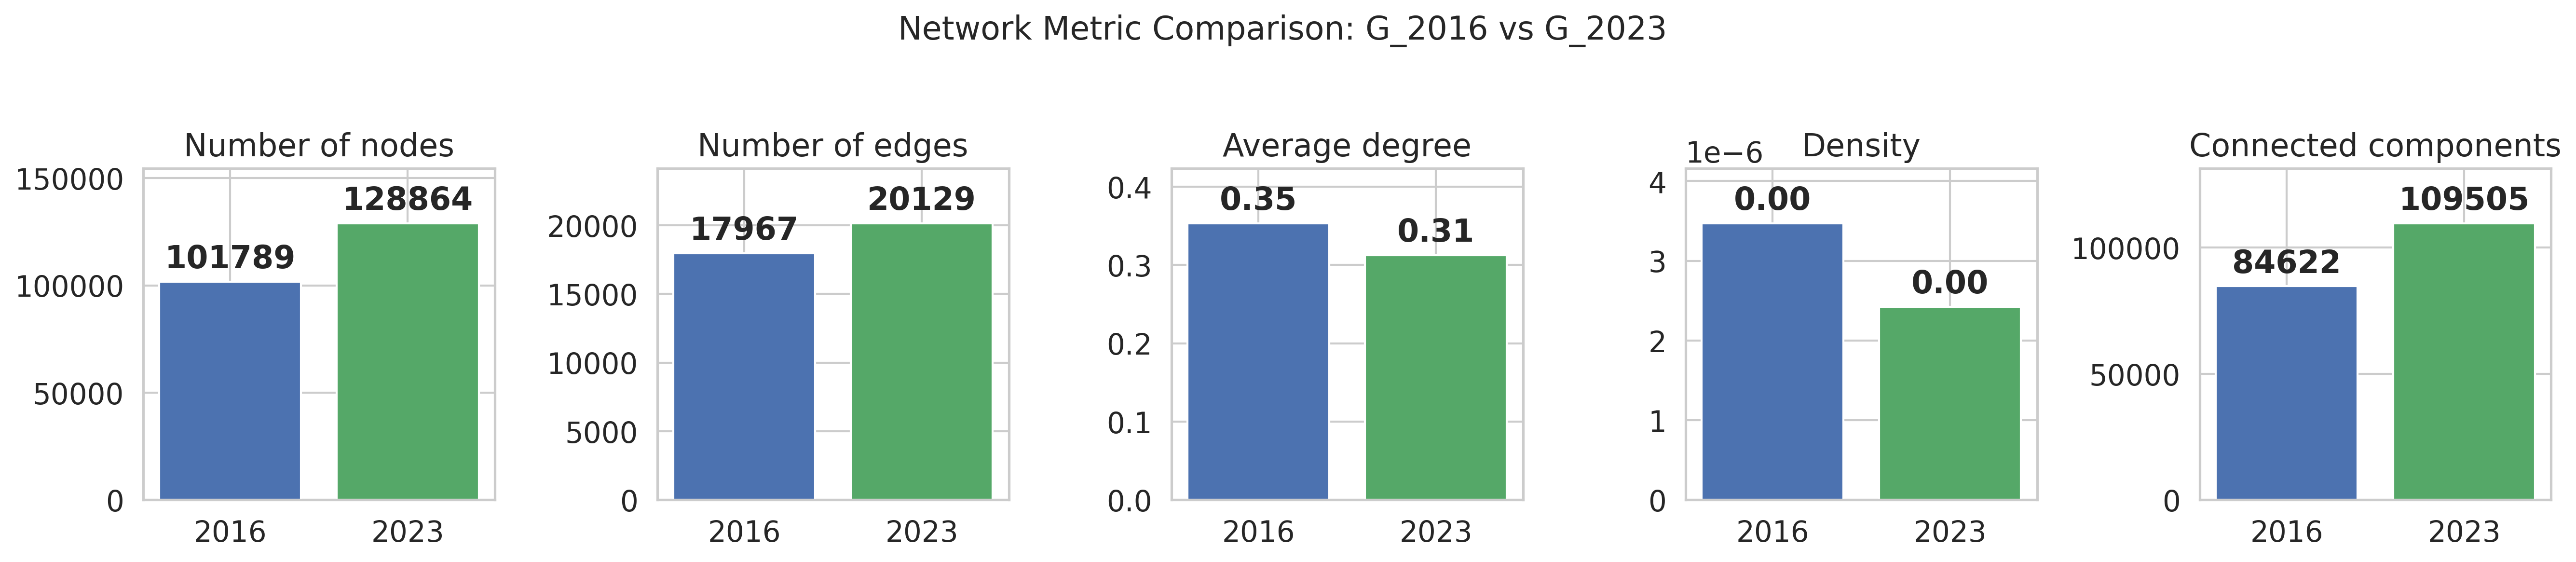

In [21]:
import networkx as nx
import matplotlib.pyplot as plt

# Your graph info
graphs = {'2016': G_2016, '2023': G_2023}

metrics = {
    'Number of nodes': [],
    'Number of edges': [],
    'Average degree': [],
    'Density': [],
    'Connected components': []
}

for year, G in graphs.items():
    metrics['Number of nodes'].append(G.number_of_nodes())
    metrics['Number of edges'].append(G.number_of_edges())
    avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
    metrics['Average degree'].append(avg_degree)
    metrics['Density'].append(nx.density(G))
    metrics['Connected components'].append(nx.number_connected_components(G))

# Plotting
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, (metric_name, values) in enumerate(metrics.items()):
    axes[i].bar(graphs.keys(), values, color=['#4c72b0', '#55a868'])
    axes[i].set_title(metric_name)
    axes[i].set_ylim(0, max(values)*1.2)
    for j, v in enumerate(values):
        axes[i].text(j, v + max(values)*0.05, f"{v:.2f}" if isinstance(v, float) else f"{v}", ha='center', fontweight='bold')

plt.suptitle('Network Metric Comparison: G_2016 vs G_2023', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()